## Simulating data from empirical parameter estimates from Shekhar and Rahnev (2021)

To investigate the added value of estimating the autoregressive coefficient, instead of fixing it to .9995 (Gupta & Brody) or to 1.0 (Roy) we simulate data with the empirical parameter estimates of Shekhar and Rahnev. Next, we fit hMFC but with the AR coefficient fixed to .9995. We then compare these fits with the hMFC fits where the AR coefficient is estimated. 

To fit hMFC with a fixed AR coefficient we initialize $\mu_a$ = .9995 and $\sigma_a$ = .0001. Next we disable the group-level Gibbs step for both these parameters, and we adjust the gibbs step for the per-subject $a_i$ estimating such that it always return the value .9995.

In [15]:
import equinox as eqx
import jax
from jax import vmap, lax
import jax.numpy as jnp
import jax.random as jr
from jax.nn import sigmoid
from jaxtyping import Float, Array
from typing import Union
from functools import partial
import matplotlib.pyplot as plt
import seaborn as sns
from fastprogress import progress_bar
from scipy.stats import spearmanr
import dill
from matplotlib.backends.backend_pdf import PdfPages
from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
tfb = tfp.bijectors


from hmfc.gibbs import gibbs_step_states, random_walk_mh, gibbs_step_global_params, gibbs_step_pg
from hmfc.utils import convert_mean_to_std_ig_params
from hmfc.lds import _sample_info_gaussian
from hmfc.constants import SIGMASQ0

In [16]:
A_MAX = 0.99999

In [17]:
class HierarchicalBernoulliLDS(eqx.Module):
    r"""
    Implementation of the model.
    """
    # Hyperparameters of the prior distributions
    log_lambda_mu : Float = 3.0               # rate of the exponential prior on mu (mean of inverse gamma prior for sigmasq of latent states)
    log_lambda_beta  : Float = 3.0            # rate of the exponential prior on beta (scale of inverse gamma prior for sigmasq of latent states)
    
    # Global parameters of the model
    mu_w       : Float[Array, "num_inputs"]   # mean normal for input weights
    log_sigma_w  : Float[Array, "num_inputs"] # sd normal for input weights
    logit_mu_a : Float = 10.0                 # mean truncated normal for autoregressive coefficients (latent states) in unconstrained form (allows HMC)
    log_sigma_a  : Float = -1.0               # sd truncated normal for autoregressive coefficient (latent states) in unconstrained form
    log_sigma_mu_x : Float = -1.0             # sd normal for mu_x
    log_mu_sigmasq: Float = -2.3              # log of the mean of sigmasq (variance of latent states)
    log_beta_sigmasq: Float = -2.3            # log of the scale of sigmasq (variance of latent states)

    def __init__(self, 
                 num_inputs : int,
                 mu_a : float = 0.99, 
                 sigma_a : float = 0.1, 
                 mu_w: Union[float, Float[Array, "num_inputs"]] = 0.0, 
                 sigma_w: Union[float, Float[Array, "num_inputs"]] = 1.0,
                 mu_sigmasq: float = 0.1, 
                 beta_sigmasq: float = 0.1, 
                 sigma_mu_x: float = 1.0, 
                 lambda_mu: float = 10., 
                 lambda_beta: float = 10.):
        
        # Set the hyperparameters
        self.log_lambda_mu = jnp.log(lambda_mu)
        self.log_lambda_beta = jnp.log(lambda_beta)
        
        # Set the global parameters
        self.logit_mu_a = jnp.log(mu_a / (1 - mu_a))
        self.log_sigma_a = jnp.log(sigma_a)
        self.mu_w = mu_w if isinstance(mu_w, jnp.ndarray) else jnp.full((num_inputs,), mu_w)
        self.log_sigma_w = jnp.log(sigma_w) if isinstance(sigma_w, jnp.ndarray) else jnp.full((num_inputs,), jnp.log(sigma_w))
        self.log_sigma_mu_x = jnp.log(sigma_mu_x)
        self.log_mu_sigmasq = jnp.log(mu_sigmasq)
        self.log_beta_sigmasq = jnp.log(beta_sigmasq)

    @property
    def num_inputs(self):
        return self.mu_w.shape[0]
    
    @property
    def lambda_mu(self):
        return jnp.exp(self.log_lambda_mu)
    
    @property
    def lambda_beta(self):
        return jnp.exp(self.log_lambda_beta)
    
    @property
    def sigma_w(self):
        return jnp.exp(self.log_sigma_w)
    
    @property
    def mu_a(self):
        return sigmoid(self.logit_mu_a)
    
    @property
    def sigma_a(self):
        return jnp.exp(self.log_sigma_a)
    
    @property
    def sigma_mu_x(self):
        return jnp.exp(self.log_sigma_mu_x)

    @property
    def mu_sigmasq(self):
        return jnp.exp(self.log_mu_sigmasq)
    
    @property
    def beta_sigmasq(self):
        return jnp.exp(self.log_beta_sigmasq)

    def sample(self,
               key,
               inputs : Float[Array, "num_subjects num_trials num_inputs"]
               ):
        r"""
        Draw a sample from the generative model.
        """
        num_subjects, num_trials, num_inputs = inputs.shape
        assert num_inputs == self.mu_w.shape[0]

        def _sample_one(key, u_i):
            k1, k2, k3, k4, k5, k6, k7 = jr.split(key, 7)

            # Sample per trial parameters
            w_i = tfd.Normal(self.mu_w, self.sigma_w).sample(seed=k1)
        
            a_i = tfd.TruncatedNormal(self.mu_a, self.sigma_a, 0.0, A_MAX).sample(seed=k2)
            
            sigmasq_i = tfd.InverseGamma(
                *convert_mean_to_std_ig_params(self.mu_sigmasq, self.beta_sigmasq)
            ).sample(seed=k3)

            mu_x_i = tfd.Normal(0, self.sigma_mu_x).sample(seed=k4)
            b_i = mu_x_i * (1 - a_i)
 
            # Sample latent states starting at the stationary distribution
            # Stationary covariance is \sigma_0^2 = \sigma^2 / (1 - a^2)
            # but for simplicity, we assume the initial variance is 1.0
            x_it0 = tfd.Normal(mu_x_i, jnp.sqrt(SIGMASQ0)).sample(seed=k5)
  
            def _step(x_itp, key):
                x_itp1 = tfd.Normal(a_i * x_itp + b_i, jnp.sqrt(sigmasq_i)).sample(seed=key)
                return x_itp1, x_itp
            _, x_it = lax.scan(_step, x_it0, jr.split(k6, num_trials))

            # Sample emissions
            y_it = tfd.Bernoulli(x_it + u_i @ w_i).sample(seed=k7)
            return dict(a=a_i, mu_x=mu_x_i, w=w_i, sigmasq=sigmasq_i), x_it, y_it

        return vmap(_sample_one)(jr.split(key, num_subjects), inputs)


    def log_prob(self,
                 emissions : Float[Array, "num_subjects num_trials"],
                 masks : Float[Array, "num_subjects num_trials"],
                 states : Float[Array, "num_subjects num_trials"],
                 inputs : Float[Array, "num_subjects num_trials num_inputs"],
                 params : dict):
        def _single_lp(y_it, m_i, x_it, u_i, params_i):
            a_i = params_i["a"]
            mu_x_i = params_i["mu_x"]
            w_i = params_i["w"]
            sigmasq_i = params_i["sigmasq"]

            # Derive b_i from mu_x_i and a_i
            b_i = mu_x_i * (1 - a_i)

            # \log p(\theta_i | \eta)
            lp_i = tfd.TruncatedNormal(self.mu_a, self.sigma_a, 0.0, A_MAX).log_prob(a_i)
            lp_i += tfd.Normal(0.0, self.sigma_mu_x).log_prob(mu_x_i)
            lp_i += tfd.Normal(self.mu_w, self.sigma_w).log_prob(w_i)
            lp_i += tfd.InverseGamma(
                *convert_mean_to_std_ig_params(self.mu_sigmasq, self.beta_sigmasq)
                ).log_prob(sigmasq_i)

            # \log p(x_it | \theta_i)
            lp_i += tfd.Normal(mu_x_i, jnp.sqrt(SIGMASQ0)).log_prob(x_it[0])
            lp_i += tfd.Normal(a_i * x_it[:-1] + b_i, jnp.sqrt(sigmasq_i)).log_prob(x_it[1:]).sum()

            # \log p(y_it | x_it, u_i, \theta_i)
            lp_i += jnp.sum(m_i * tfd.Bernoulli(x_it + u_i @ w_i).log_prob(y_it)) # m_i is mask (if 0 then just sum 0)
            return lp_i

        return vmap(_single_lp)(emissions, masks, states, inputs, params).sum()


In [18]:
def gibbs_step_local_params_fixed_a(key,
                                    emissions : Float[Array, "num_subjects num_trials"],
                                    masks: Float[Array, "num_subjects num_trials"],
                                    states: Float[Array, "num_subjects num_trials"],
                                    inputs : Float[Array, "num_subjects num_trials num_inputs"],
                                    pg_samples : Float[Array, "num_subjects num_trials"],
                                    params: dict,
                                    model : HierarchicalBernoulliLDS,
                                    ):
    r"""
    Perform one Gibbs step to update the local parameters.
    """
    num_subjects, num_trials, num_inputs = inputs.shape
    mu_a = sigmoid(model.logit_mu_a)
    sigma_a = jnp.exp(model.log_sigma_a)
    mu_w = model.mu_w
    sigma_w = jnp.exp(model.log_sigma_w)
    sigma_mu_x = jnp.exp(model.log_sigma_mu_x)
    
    def _sample_one(key, y_it, m_i, x_it, u_i, pg_i, params_i):
        k1, k2, k3, k4 = jr.split(key, 4)

        # Gibbs sample the input weights
        J_w = 1.0 / sigma_w**2 * jnp.eye(num_inputs)
        J_w += jnp.einsum('ti,tj,t,t->ij', u_i, u_i, m_i, pg_i)
        J_w = 0.5 * (J_w + J_w.T)
        h_w = mu_w / sigma_w**2
        h_w += jnp.einsum('t,t,ti->i', y_it - pg_i * x_it - 0.5, m_i, u_i)
        w_i = _sample_info_gaussian(k1, J_w, h_w)

        # Gibbs sample the dynamics coefficient (given sigmasq_i, b_i, and rest)
        a_i = params_i["a"]
        mu_x_i = params_i["mu_x"]
        b_i = mu_x_i * (1 - a_i)
        sigmasq_i = params_i["sigmasq"]
        J_a = 1.0 / sigma_a**2 + jnp.sum(m_i[1:] * x_it[:-1]**2) / sigmasq_i
        h_a = mu_a / sigma_a**2 + jnp.sum(m_i[1:] * x_it[:-1] * (x_it[1:] - b_i)) / sigmasq_i
        a_i = tfd.TruncatedNormal(h_a / J_a, jnp.sqrt(1.0 / J_a), 0.0, A_MAX).sample(seed=k2)

        # Gibbs sample the bias term (given a_i and rest)
        # p(mu_x | a, x)
        # \propto N(mu_x | 0, sigma_mu_x^2) N(x_1 | mu_x, 1) \prod_{t=1}^{T-1} N(x_{t+1} - a x_t|  mu_x (1 - a), \sigma^2)
        # \propto N(mu_x | 0, sigma_mu_x^2) N(x_1 | mu_x, 1) \prod_{t=1}^{T-1} N((x_{t+1} - a x_t) / (1 - a) |  mu_x , \sigma^2 / (1 - a)^2)
        J_mu_x = 1/sigma_mu_x**2 + m_i[0] + jnp.sum(m_i[1:]) * (1 - a_i)**2 / sigmasq_i
        h_mu_x = 0 + m_i[0] * x_it[0] + jnp.sum(m_i[1:] * (x_it[1:] - a_i * x_it[:-1]) / (1 - a_i)) * (1 - a_i)**2 / sigmasq_i
        mu_x_i = tfd.Normal(h_mu_x / J_mu_x, jnp.sqrt(1.0 / J_mu_x)).sample(seed=k3)
        b_i = mu_x_i * (1 - a_i)

        # Gibbs sample the dynamics noise variance (given a_i and rest)
        alpha0, beta0 = convert_mean_to_std_ig_params(model.mu_sigmasq, model.beta_sigmasq)
        alpha_post = alpha0 + 0.5 * jnp.sum(m_i[1:])
        beta_post = beta0 + 0.5 * jnp.sum(m_i[1:] * (x_it[1:] - a_i * x_it[:-1] - b_i)**2)
        sigmasq_i = tfd.InverseGamma(alpha_post, beta_post).sample(seed=k4)
        return dict(a=0.9995, mu_x=mu_x_i, w=w_i, sigmasq=sigmasq_i)

    return vmap(_sample_one)(jr.split(key, num_subjects),
                             emissions,
                             masks,
                             states,
                             inputs,
                             pg_samples,
                             params)

In [19]:
def _gibbs_step_global_ar(key,
                          model: HierarchicalBernoulliLDS,
                          params: dict,
                          proposal_variance: float=0.05**2,
                          num_steps: int=20):
    r"""
    Update the global params mu_a, sigma_a with RWMH
    """
    def _log_prob(logit_mu_a):
        lp = tfd.TransformedDistribution(
            tfd.Uniform(0, A_MAX),
            tfb.Invert(tfb.Sigmoid()),
        ).log_prob(logit_mu_a)

        lp += tfd.TruncatedNormal(sigmoid(logit_mu_a), jnp.exp(model.log_sigma_a),
                                  0.0, A_MAX).log_prob(params["a"]).sum()
        return lp

    logit_mu_a = random_walk_mh(key,
                               _log_prob,
                               model.logit_mu_a,
                               proposal_variance,
                               num_steps)

    model = eqx.tree_at(lambda m: m.logit_mu_a, model, logit_mu_a)

    return model

def _gibbs_step_global_ar_var(key,
                              model: HierarchicalBernoulliLDS,
                              params: dict,
                              proposal_variance: float=0.05**2,
                              num_steps: int=20):
    r"""
    Update the global params mu_a, sigma_a with RWMH
    """

    def _log_prob(log_sigma_a):
        lp = tfd.TransformedDistribution(
            tfd.Uniform(0, SIGMA_A_MAX),
            tfb.Log(),
        ).log_prob(log_sigma_a)

        # log likelihood: \sum_i log p(a_i | mu_a, \sigma_a^2)
        lp += tfd.TruncatedNormal(sigmoid(model.logit_mu_a), jnp.exp(log_sigma_a),
                                  0.0, A_MAX).log_prob(params["a"]).sum()
        return lp

    log_sigma_a = random_walk_mh(key,
                              _log_prob,
                              model.log_sigma_a,
                              proposal_variance,
                              num_steps)

    model = eqx.tree_at(lambda m: m.log_sigma_a, model, log_sigma_a)
    return model

In [20]:
@partial(jax.jit, static_argnums=(7, 8, 9, 10, 11))
def gibbs_step_fixed_a(key,
                       emissions : Float[Array, "num_subjects num_trials"],
                       masks: Float[Array, "num_subjects num_trials"],
                       states: Float[Array, "num_subjects num_trials"],
                       inputs : Float[Array, "num_subjects num_trials num_inputs"],
                       params: dict,
                       model : HierarchicalBernoulliLDS,
                       update_global_weights: bool=True,
                       update_global_ar: bool=True,
                       update_global_ar_var: bool=True,
                       update_global_mu_sigmasq: bool=True,
                       update_global_beta_sigmasq: bool=True
                       ):
    k1, k2, k3, k4 = jr.split(key, 4)

    # 0. Evaluate log joint probability
    lp = model.log_prob(emissions, masks, states, inputs, params)

    # 1. Sample PG auxiliary variables
    pg_samples = gibbs_step_pg(k1, states, inputs, params)

    # 2. Sample local params
    params = gibbs_step_local_params_fixed_a(k2, emissions, masks, states, inputs, pg_samples, params, model)

    # 3. Sample new latent states
    states = gibbs_step_states(k3, emissions, masks, inputs, pg_samples, params)

    # 4. Sample new global params
    model = gibbs_step_global_params(k4, model, params,
                                     update_global_weights=update_global_weights,
                                     update_global_ar=update_global_ar,
                                     update_global_ar_var=update_global_ar_var,
                                     update_global_mu_sigmasq=update_global_mu_sigmasq,
                                     update_global_beta_sigmasq=update_global_beta_sigmasq)

    return lp, states, params, model

### Load in estimated parameters and data

In [21]:
file_name = 'C:/Users/u0141056/OneDrive - KU Leuven/PhD/PROJECTS/CHOICE HISTORY BIAS/Correction slow drifts/hMFC/hMFC/Paper/simulations empirical dataset/Shekhar_2021.dil'

g = globals()
with open(file_name,'rb') as file:
    list_of_variable_names = dill.load(file)  # Get the names of stored objects
    for variable_name in list_of_variable_names:
        g[variable_name] = dill.load(file)    # Get the objects themselves
        

### Draw emissions and states based on data and estimated parameters from Shekhar

In [22]:
def sample_emissions_states(key,
           inputs,
           w_i,
           a_i,
           sigmasq_i,
           mu_x_i
           ):

    num_subjects, num_trials, num_inputs = inputs.shape

    def _sample_one_subject(key, u_i, w_i, a_i, sigmasq_i, mu_x_i):
        
        k1, k2, k3 = jr.split(key, 3)

        sigmasq0_i = 1.0
        b_i = mu_x_i * (1 - a_i)
        
        # Sample latent states starting at the stationary distribution
        # Stationary covariance is \sigmmu_a^2 = \sigma^2 / (1 - a^2)
        x_i0 = tfd.Normal(mu_x_i, jnp.sqrt(sigmasq0_i)).sample(seed=k1)
  
        def _step(x_it, key):
            x_itp1 = tfd.Normal(a_i * x_it + b_i, jnp.sqrt(sigmasq_i)).sample(seed=key)
            return x_itp1, x_it
        _, x_i = lax.scan(_step, x_i0, jr.split(k2, num_trials))

        # Sample emissions
        y_i = tfd.Bernoulli(x_i + u_i @ w_i).sample(seed=k3)
        return dict(a=a_i, mu_x=mu_x_i, w=w_i, sigmasq=sigmasq_i), x_i, y_i

    return vmap(_sample_one_subject)(jr.split(key, num_subjects), inputs, w_i, a_i, sigmasq_i, mu_x_i)

In [23]:
burn_in = 500

# Load in Shekhar parameters
a_i = jnp.mean(posterior_samples_a[burn_in:,:], axis=0)
sigmasq_i = jnp.mean(posterior_samples_sigmasq[burn_in:,:], axis=0)
mu_x_i = jnp.mean(posterior_samples_mu_x[burn_in:,:], axis=0)
w_i = jnp.mean(posterior_samples_w[burn_in:,:,:], axis=0)

# Sample states and emissions
key = jr.PRNGKey(0)
true_params, true_states, emissions = sample_emissions_states(key, inputs, w_i, a_i, sigmasq_i, mu_x_i)


### Initialize model and make it a random walk


In [25]:
num_iters = 2000

# Assume random walk for criterion fluctuations
init_mu_a = 0.9999
init_sigma_a = 0.0001
init_mu_w = jnp.zeros(num_inputs)
init_sigma_w = jnp.repeat(1.0, num_inputs)
init_mu_sigmasq = 3.0
init_beta_sigmasq = 3.0 * 0.3**2
init_sigma_mu_x = 0.5

model = HierarchicalBernoulliLDS(num_inputs, init_mu_a, init_sigma_a, init_mu_w, init_sigma_w, init_mu_sigmasq, init_beta_sigmasq, init_sigma_mu_x)
params, states, _ = model.sample(key, inputs)

### Fit model
Here we don't update $\mu_a$ and $\sigma_a$ and keep it at its initialized value.

In [15]:
lps = jnp.zeros((num_iters,)) # log probability

posterior_samples_mu_a = jnp.zeros((num_iters,))
posterior_samples_sigma_a = jnp.zeros((num_iters,))
posterior_samples_mu_w = jnp.zeros((num_iters, num_inputs))
posterior_samples_sigma_w = jnp.zeros((num_iters, num_inputs))
posterior_samples_mu_sigmasq = jnp.zeros((num_iters,))
posterior_samples_beta_sigmasq = jnp.zeros((num_iters,))
posterior_samples_sigma_mu_x = jnp.zeros((num_iters,))

posterior_samples_a = jnp.zeros((num_iters, num_subjects))
posterior_samples_sigmasq = jnp.zeros((num_iters, num_subjects))
posterior_samples_w = jnp.zeros((num_iters, num_subjects, num_inputs))
posterior_samples_mu_x = jnp.zeros((num_iters, num_subjects))

posterior_samples_states = jnp.zeros((num_iters, num_subjects, num_trials))

for itr in progress_bar(range(num_iters)):

    this_key, key = jr.split(key)
    lp, states, params, model = gibbs_step_fixed_a(this_key, emissions, masks, states, inputs, params, model, update_global_ar=False, update_global_ar_var=False)
    
    lps = lps.at[itr].set(lp)

    posterior_samples_mu_a = posterior_samples_mu_a.at[itr].set(sigmoid(model.logit_mu_a))
    posterior_samples_sigma_a = posterior_samples_sigma_a.at[itr].set(jnp.exp(model.log_sigma_a))
    posterior_samples_mu_w = posterior_samples_mu_w.at[itr].set(model.mu_w)
    posterior_samples_sigma_w = posterior_samples_sigma_w.at[itr].set(jnp.exp(model.log_sigma_w))
    posterior_samples_mu_sigmasq = posterior_samples_mu_sigmasq.at[itr].set(jnp.exp(model.log_mu_sigmasq))
    posterior_samples_beta_sigmasq = posterior_samples_beta_sigmasq.at[itr].set(jnp.exp(model.log_beta_sigmasq))
    posterior_samples_sigma_mu_x = posterior_samples_sigma_mu_x.at[itr].set(jnp.exp(model.log_sigma_mu_x))


    posterior_samples_a = posterior_samples_a.at[itr].set(params['a'])
    posterior_samples_sigmasq = posterior_samples_sigmasq.at[itr].set(params['sigmasq'])
    posterior_samples_w = posterior_samples_w.at[itr].set(params['w'])
    posterior_samples_mu_x = posterior_samples_mu_x.at[itr].set(params['mu_x'])
    
    posterior_samples_states = posterior_samples_states.at[itr].set(states)

### Save the data

In [ ]:
file_name = './Shekhar_simulations_random_walk.dil'

list_of_variable_names = ("lps", "true_states",
  "posterior_samples_mu_a", "posterior_samples_sigma_a",
  "posterior_samples_mu_sigmasq", "posterior_samples_beta_sigmasq",
  "posterior_samples_mu_w", "posterior_samples_sigma_w",
  "posterior_samples_sigma_mu_x", "posterior_samples_mu_x",
  "posterior_samples_a","posterior_samples_sigmasq",
  "posterior_samples_w", "posterior_samples_states")


with open(file_name, 'wb') as file:
    dill.dump(list_of_variable_names, file)  # Store all the names first
    
    for variable_name in list_of_variable_names:
        dill.dump(eval(variable_name), file) # Store the objects themselves

### Load the data

In [26]:
file_name = 'C:/Users/u0141056/OneDrive - KU Leuven/PhD/PROJECTS/CHOICE HISTORY BIAS/Correction slow drifts/hMFC/hMFC/Paper/simulations empirical dataset/Shekhar_simulations_random_walk.dil'

g = globals()
with open(file_name,'rb') as file:
    list_of_variable_names = dill.load(file)  # Get the names of stored objects
    for variable_name in list_of_variable_names:
        g[variable_name] = dill.load(file)    # Get the objects themselves

### Log prob

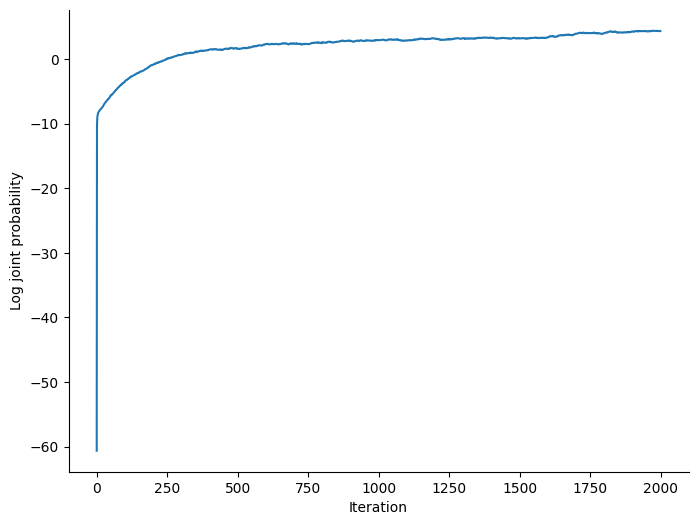

In [27]:
burn_in = 500 # choose a different value informed by the plot below

plt.figure(figsize=(8, 6))
plt.plot(jnp.stack(lps)/emissions.size) # normalized log joint prob
plt.xlabel("Iteration")
plt.ylabel("Log joint probability")
sns.despine()
plt.show()

### Compare true and inferred estimates of mu_x_i averaged over iterations

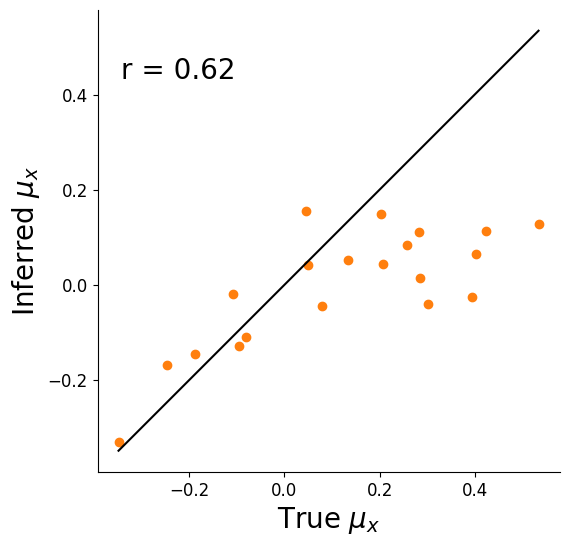

In [29]:
# Compute posterior mean of mu_x_i for each subject over iterations
posterior_mean_mu_x = jnp.mean(posterior_samples_mu_x[burn_in:], axis=0)

mu_x_min = min(true_params['mu_x'].min(), posterior_mean_mu_x.min())
mu_x_max = max(true_params['mu_x'].max(), posterior_mean_mu_x.max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['mu_x'], posterior_mean_mu_x, color="#FF7F0E")
plt.plot([mu_x_min, mu_x_max], [mu_x_min, mu_x_max], '-k')
plt.xlabel("True $\mu_x$", size=20)
plt.ylabel("Inferred $\mu_x$", size=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['mu_x'], posterior_mean_mu_x)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction', size=20)
sns.despine()
plt.show()

### Compare true and inferred estimates of a_i averaged over iterations

C:\Users\u0141056\AppData\Local\Temp\ipykernel_4420\2064474648.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(true_params['a'], posterior_mean_a)


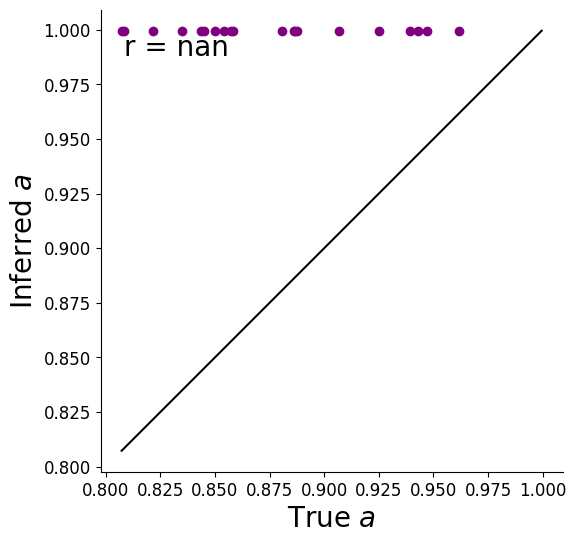

In [30]:
# Compute posterior mean of a_i for each subject over iterations
posterior_mean_a = jnp.mean(posterior_samples_a[burn_in:], axis=0)

a_min = min(true_params['a'].min(), posterior_mean_a.min())
a_max = max(true_params['a'].max(), posterior_mean_a.max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['a'], posterior_mean_a, color="purple")
plt.plot([a_min, a_max], [a_min, a_max], '-k')
plt.xlabel("True $a$", size=20)
plt.ylabel("Inferred $a$", size=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['a'], posterior_mean_a)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.9), xycoords='axes fraction', size=20)
sns.despine()
plt.savefig("shekhar_a_rw.png", transparent=True, dpi=600)

### Compare true and inferred estimates of sigmasq_i averaged over iterations

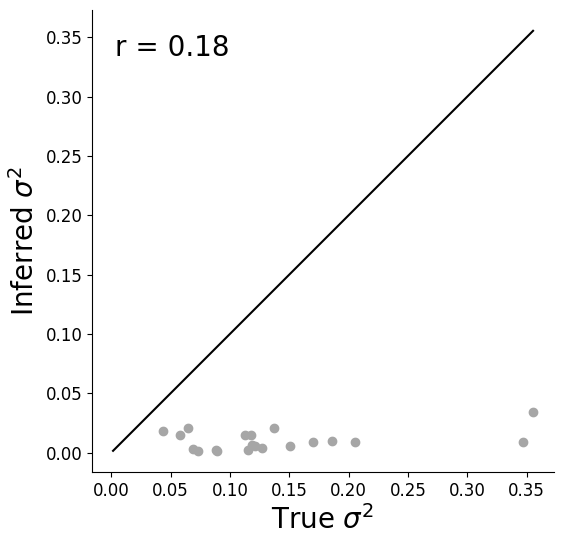

In [31]:
# Compute posterior mean of sigmasq_i for each subject over iterations
posterior_mean_sigmasq = jnp.mean(posterior_samples_sigmasq[burn_in:], axis=0)

sigmasq_min = min(true_params['sigmasq'].min(), posterior_mean_sigmasq.min())
sigmasq_max = max(true_params['sigmasq'].max(), posterior_mean_sigmasq.max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['sigmasq'], posterior_mean_sigmasq, color="#A6A6A6")
plt.plot([sigmasq_min, sigmasq_max], [sigmasq_min, sigmasq_max], '-k')
plt.xlabel("True $\sigma^2$", size=20)
plt.ylabel("Inferred $\sigma^2$", size=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['sigmasq'], posterior_mean_sigmasq)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.9), xycoords='axes fraction', size=20)
sns.despine()
plt.savefig("shekhar_sigma_rw.png", transparent=True, dpi=600)

### Compare true and inferred estimates of w_i averaged over iterations

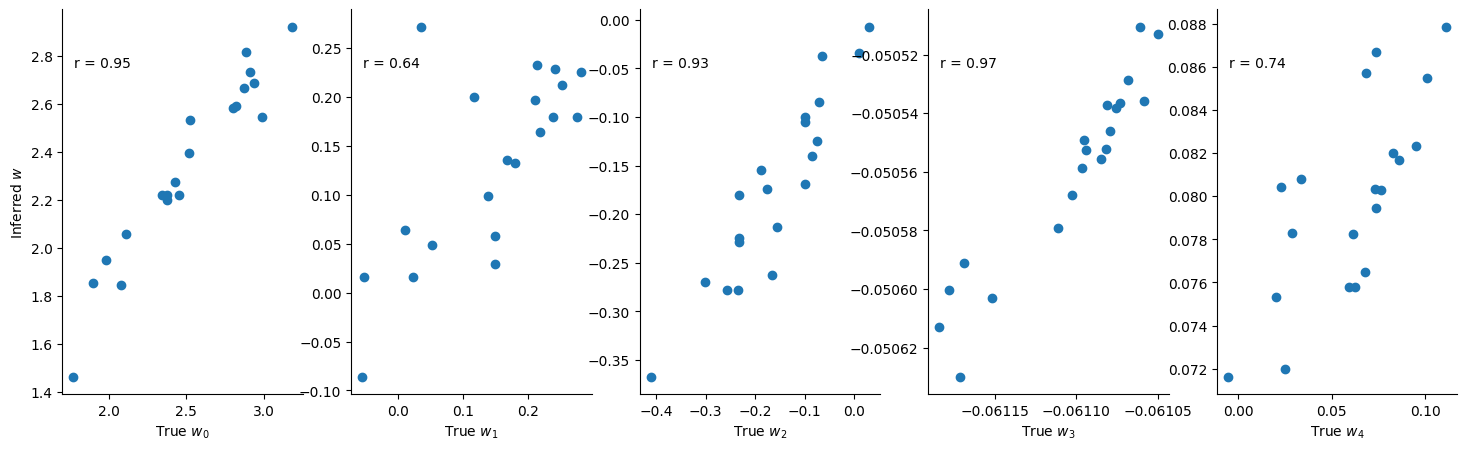

In [18]:
w_min = min(true_params["w"].min(), jnp.mean(posterior_samples_w[burn_in:,:,:], axis=0).min())
w_max = max(true_params["w"].max(), jnp.mean(posterior_samples_w[burn_in:,:,:], axis=0).max())

fig, axs = plt.subplots(1, num_inputs, sharey=False, figsize=(18, 5))

for d, ax in enumerate(axs):
    ax.scatter(true_params["w"][:, d], jnp.mean(posterior_samples_w[burn_in:,:,d], axis=0))
    ax.set_xlabel(r"True $w_{:d}$".format(d))
    if d == 0:
        ax.set_ylabel(r"Inferred $w$".format(d))
    #ax.plot([w_min, w_max], [w_min, w_max], '-k')
    #ax.set_aspect(1.0)
    r, p = spearmanr(true_params["w"][:, d], jnp.mean(posterior_samples_w[burn_in:,:,d], axis=0))
    ax.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
    sns.despine()



### Correlation between inferred and fitted criterion trajectories over all subjects

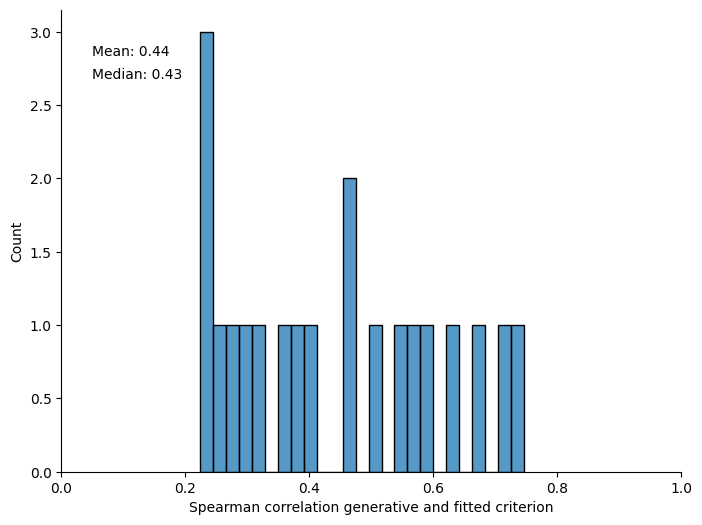

In [19]:
posterior_samples_states_mean = jnp.mean(posterior_samples_states[burn_in:,:,:], axis=0) 
posterior_samples_states_std = jnp.std(posterior_samples_states[burn_in:,:,:], axis=0)

correlations_inferred_and_fitted_states = jnp.array([spearmanr(true_states[subject], posterior_samples_states_mean[subject])[0] for subject in range(num_subjects)])

mean_value = jnp.mean(correlations_inferred_and_fitted_states)
median_value = jnp.median(correlations_inferred_and_fitted_states)

plt.figure(figsize=(8, 6))
sns.histplot(correlations_inferred_and_fitted_states, bins=25)
plt.annotate(f'Mean: {mean_value:.2f}', xy=(0.05, 0.90), xycoords='axes fraction')
plt.annotate(f'Median: {median_value:.2f}', xy=(0.05, 0.85), xycoords='axes fraction')
plt.xlabel('Spearman correlation generative and fitted criterion')
plt.ylabel('Count')
plt.xlim(0, 1)
sns.despine()
plt.show()


### Correlation between inferred and fitted criterion trajectories per subject

In [24]:
trial_limit = 2790

In [25]:
with PdfPages('estimated_criterion_fluct_Shekhar_random_walk.pdf') as pdf:
    for subject in range(num_subjects):
      
        plt.figure(figsize=(8, 6))
        plt.plot(true_states[subject][:trial_limit], label="True states", linewidth=2, color='red', alpha=.6)
        plt.plot(posterior_samples_states_mean[subject][:trial_limit], label="Inferred states", linewidth=2.5)
        plt.fill_between(jnp.arange(trial_limit), #95% CI
                  posterior_samples_states_mean[subject, :trial_limit] - 2 * posterior_samples_states_std[subject, :trial_limit],
                  posterior_samples_states_mean[subject, :trial_limit] + 2 * posterior_samples_states_std[subject, :trial_limit], color='r', alpha=0.25)
        plt.xlabel("Trial")
        plt.ylabel("Criterion $x_t$")
        plt.title(r"Subject {:d}".format(subject))
        plt.legend(loc='lower right')
        r, p = spearmanr(true_states[subject], posterior_samples_states_mean[subject])
        rmse = jnp.sqrt(jnp.mean((true_states[subject]-posterior_samples_states_mean[subject])**2))
        plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.90), xycoords='axes fraction')
        plt.annotate('rmse = {:.2f}'.format(rmse), xy=(0.05, 0.85), xycoords='axes fraction')
        sns.despine()
        
        pdf.savefig()
        plt.close()

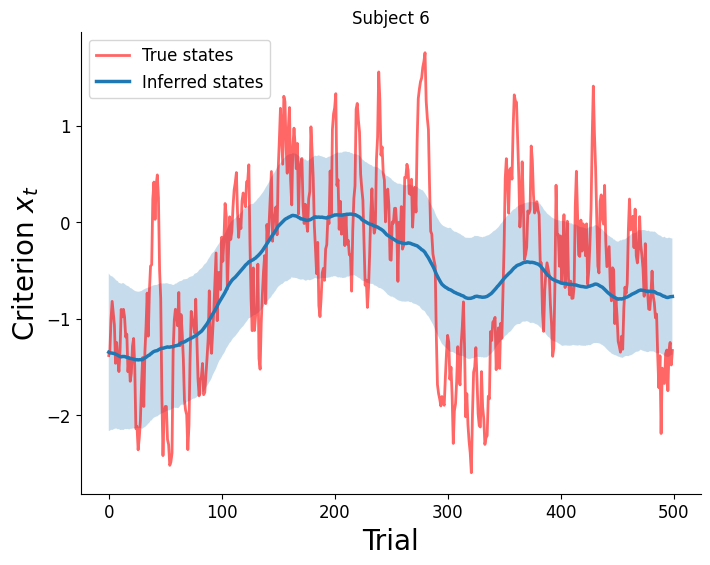

In [32]:
subject = 6
trial_limit = 500

plt.figure(figsize=(8, 6))
plt.plot(true_states[subject][:trial_limit], label="True states", linewidth=2, color='red', alpha=.6)
plt.plot(posterior_samples_states_mean[subject][:trial_limit], label="Inferred states", linewidth=2.5)
plt.fill_between(jnp.arange(trial_limit), #95% CI
          posterior_samples_states_mean[subject, :trial_limit] - 2 * posterior_samples_states_std[subject, :trial_limit],
          posterior_samples_states_mean[subject, :trial_limit] + 2 * posterior_samples_states_std[subject, :trial_limit], alpha=0.25)
plt.xlabel("Trial", size=20)
plt.ylabel("Criterion $x_t$", size=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title(r"Subject {:d}".format(subject))
plt.legend(loc='upper left', fontsize=12)
r, p = spearmanr(true_states[subject], posterior_samples_states_mean[subject])
#plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.90), xycoords='axes fraction')
sns.despine()
plt.savefig("shekhar_example_subject_random_walk.png", transparent=True, dpi=600)